In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
np.random.seed(42)
torch.manual_seed(42)

In [3]:
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
def preprocesss(file_path,seq_len=50):
    dat = np.load(file_path)[:,4000:8000,:] 
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    data = data.reshape(data.shape[0]//seq_len, seq_len, 53*3)
    data = torch.tensor(data,dtype=torch.float)
    return data

In [5]:
data=preprocesss(file_path)
data.shape
# 80 eg of 50 seq len

torch.Size([80, 50, 159])

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 48.65it/s]


Saved animate/temppp.gif and animate/temppp.mp4


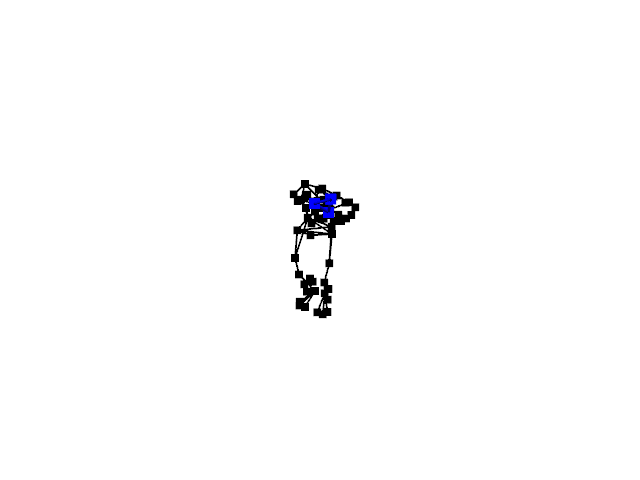

In [7]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 0:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.50) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")
def visualize(one_seq,filename='temppp'):
    path = os.path.join("animate", f"{filename}")
    inp = np.array(one_seq.detach().reshape(one_seq.shape[0],53,3))
    # print(inp.shape)
    generate_skeleton_animation(inp,output_name=path)
visualize(data[1])
from IPython.display import Image
Image(filename='animate/temppp.gif')

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class MotionAutoencoder(nn.Module):
    def __init__(self, seq_len=40, input_dim=159, latent_dim=64):
        super(MotionAutoencoder, self).__init__()
        
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(seq_len * input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * input_dim)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.reshape(batch_size, self.seq_len, self.input_dim)
        
        return reconstruction, z
    
    def encode(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        return self.encoder(x)
    
    def decode(self, z):
        batch_size = z.shape[0]
        reconstruction = self.decoder(z)
        return reconstruction.reshape(batch_size, self.seq_len, self.input_dim)

def train_autoencoder(model, data, epochs=100, batch_size=16, learning_rate=1e-3, model_path="best_autoencoder.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    num_samples = data.shape[0]
    num_batches = num_samples // batch_size
    best_loss = float('inf')  # Track minimum loss
    
    for epoch in range(epochs):
        total_loss = 0
        
        indices = np.random.permutation(num_samples)
        data = data[indices]
        
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, num_samples)
            
            batch_data = torch.tensor(data[start_idx:end_idx], dtype=torch.float32).to(device)
            
            optimizer.zero_grad()
            reconstruction, _ = model(batch_data)
            loss = criterion(reconstruction, batch_data)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches

        # Save the model if loss improves
        if avg_loss < best_loss:
            best_loss = avg_loss
            # torch.save(model.state_dict(), model_path)
            if epoch%100==0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f} , (Saved)")
        else:
            if epoch%100==0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return model

In [11]:
motion_data = data
model = MotionAutoencoder(seq_len=50, input_dim=159, latent_dim=64)

In [13]:
# trained_model = train_autoencoder(trained_model, motion_data, epochs=1000,batch_size=64,learning_rate=1e-4,model_path='best_autoencoder.pth')
# i have already trained the model you can train it again after changing the latent_dim if you want

In [23]:
model.load_state_dict(torch.load('models/best_autoencoder.pth'))
print("Best model loaded.")

Best model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 72.94it/s]


Saved animate/original.gif and animate/original.mp4


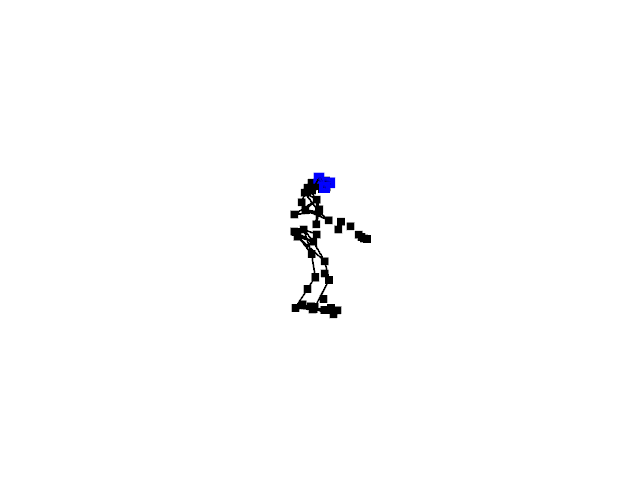

In [17]:
visualize(motion_data[0],filename='original')
Image(filename='animate/original.gif')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 83.16it/s]


Saved animate/reconstructed.gif and animate/reconstructed.mp4


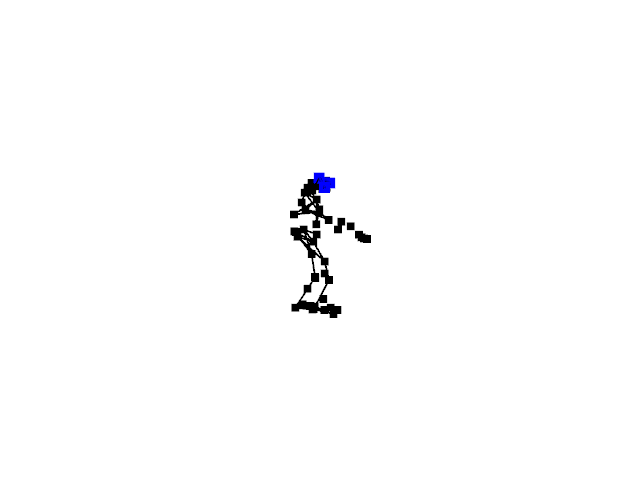

In [19]:
rec = model.decode(model.encode(motion_data[0:1])).squeeze(0)
visualize(rec,filename='reconstructed')
Image(filename='animate/reconstructed.gif')

In [21]:
# first one is the original and the below one is reconstructed 
# so in this notebook dance autencoder is trained and showed that it is working by qualitatively 